In [1]:
%reload_ext autoreload
%autoreload 2
from analysis_stm import MotionAnalyzer,ExpMetaData, DiffusionPlotter
import numpy as np
from scipy.optimize import curve_fit
import trackpy as tp
from PIL import Image
import matplotlib.pyplot as plt
from sxmreader import SXMReader
import matplotlib as mpl
import scipy
from sxmreader import SXMReader
from PIL import Image
from matplotlib.ticker import MultipleLocator
from matplotlib.animation import FuncAnimation, PillowWriter
%matplotlib inline
import ipywidgets as widgets 




In [2]:
import cv2
import numpy as np
import imageio

In [3]:
#03/07/2025
emds=[]
Vg = 60
voltages_temperatures = np.array([17])
FOLDER = "Sergey_images/images"
sets = [range(536,565),]
emd = ExpMetaData(sets, Vg, voltages_temperatures, FOLDER)
emds.append(emd)



In [4]:
SXM_PATH = [[FOLDER + f"/Image_{i}.sxm".format(i) for i in sets[j]] for j in range(len(sets))]
print(SXM_PATH)

[['Sergey_images/images/Image_536.sxm', 'Sergey_images/images/Image_537.sxm', 'Sergey_images/images/Image_538.sxm', 'Sergey_images/images/Image_539.sxm', 'Sergey_images/images/Image_540.sxm', 'Sergey_images/images/Image_541.sxm', 'Sergey_images/images/Image_542.sxm', 'Sergey_images/images/Image_543.sxm', 'Sergey_images/images/Image_544.sxm', 'Sergey_images/images/Image_545.sxm', 'Sergey_images/images/Image_546.sxm', 'Sergey_images/images/Image_547.sxm', 'Sergey_images/images/Image_548.sxm', 'Sergey_images/images/Image_549.sxm', 'Sergey_images/images/Image_550.sxm', 'Sergey_images/images/Image_551.sxm', 'Sergey_images/images/Image_552.sxm', 'Sergey_images/images/Image_553.sxm', 'Sergey_images/images/Image_554.sxm', 'Sergey_images/images/Image_555.sxm', 'Sergey_images/images/Image_556.sxm', 'Sergey_images/images/Image_557.sxm', 'Sergey_images/images/Image_558.sxm', 'Sergey_images/images/Image_559.sxm', 'Sergey_images/images/Image_560.sxm', 'Sergey_images/images/Image_561.sxm', 'Sergey_im

In [6]:
import yaml
from collections import namedtuple
def _set_search_params(emd):
    with open('params.yaml') as f:
        params = yaml.load(f, Loader=yaml.FullLoader)       
    Params = namedtuple(
                'Params', 
                ['molecule_size', 
                 'min_mass',
                 'max_mass',
                 'separation',
                 'min_size',
                 'max_ecc',
                 'adaptive_stop',
                 'search_range',
                 'diffusion_time',])
    return([Params(**params) for i in range(len(emd.voltages_temperatures))])
molecule_size, min_mass, max_mass, separation, min_size,max_ecc, adaptive_stop, search_range, _ = _set_search_params(emd)[0]

In [7]:
SXM_PATH = [[FOLDER + f"/Image_{i}.sxm".format(i) for i in sets[j]] for j in range(len(sets))]

frames_ = SXMReader(SXM_PATH[0], channel="Z", correct="plane")  # Adjust parameters as needed



In [10]:
frame_correct_par={
                   'steps':2,
                   'overide':[[22,24,25],[[10,0],[-20,-20],[20,20]]],
                   'output_crop':200,
                    'input_crop':None,
                      
}
frame_correct_par={
                   'steps':2,
                   'overide':[[],[]],
                   'output_crop':200,
                    'input_crop':None,
                      
}
def frame_correct(frames,search_params,overide=[[],[]],steps=0,
                  output_crop=None,input_crop=None,):
    molecule_size, min_mass, max_mass, separation, min_size,max_ecc, adaptive_stop, search_range=search_params
    for i in range(steps):
        f = tp.batch(frames, molecule_size, minmass=min_mass, separation=separation,engine='python')
        t = tp.link(f, search_range=search_range, adaptive_stop=adaptive_stop,memory=7)
        if i==0:
            frames=main(frames,t,molecule_size,output_crop=output_crop,input_crop=input_crop,overide=overide)
        else:
            frames=main(frames,t,molecule_size,output_crop=output_crop,input_crop=input_crop)
    return frames
new=frame_correct(frames_,(molecule_size, min_mass, max_mass, separation, min_size,max_ecc, adaptive_stop, search_range,),
             **frame_correct_par)


Frame 28: 60 trajectories present.


In [114]:
tp.compute_drift(t)['y'][1]

-0.5082064263105792

In [121]:
tp.compute_drift(t).loc[1][1]

-0.4904674307873179

In [11]:
f = tp.batch(new, molecule_size, minmass=min_mass, separation=separation,engine='python')
t = tp.link(f, search_range=search_range, adaptive_stop=adaptive_stop,memory=7)
frames=new


Frame 28: 62 trajectories present.


In [12]:
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig=plt.figure(figsize=(8, 6), dpi=120)
ax1=plt.axes(xlim=(0, 256), ylim=(0, 256), frameon=False)
plt.axis('off')
ln, = ax1.plot([], [], lw=3)
ax1.set_prop_cycle(color=['g', 'r', 'c', 'm', 'y', 'k'])
t2=t
def animate(i,):
    plt.cla()
    plt.title(i)
    plt.imshow(frames_[i])
    tp.plot_traj(t2[(t2['frame']<=i)], superimpose=frames[i], label=False, ax=ax1, plot_style={'alpha' : 1})
    ax1.set_prop_cycle(color=['g', 'r', 'c', 'm', 'y', 'k'])
#     plt.imshow(frames[i], cmap='gray')
# Set up formatting for the movie files
Writer = matplotlib.animation.writers['ffmpeg']
writer = Writer(fps=5, metadata=dict(artist='Me'), bitrate=1800)
line_ani = matplotlib.animation.FuncAnimation(fig, animate, frames=29)
# line_ani.save('claymation.mp4', writer=writer)
line_ani

In [208]:
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig=plt.figure(figsize=(8, 6), dpi=120)
ax1=plt.axes(xlim=(0, 256), ylim=(0, 256), frameon=False)
plt.axis('off')
ln, = ax1.plot([], [], lw=3)
ax1.set_prop_cycle(color=['g', 'r', 'c', 'm', 'y', 'k'])
t2=t
def animate(i,):
    plt.cla()
    plt.title(i)
    plt.imshow(new[i])
    #tp.plot_traj(t2[(t2['frame']<=i)], superimpose=frames[i], label=False, ax=ax1, plot_style={'alpha' : 1})
    #ax1.set_prop_cycle(color=['g', 'r', 'c', 'm', 'y', 'k'])
#     plt.imshow(frames[i], cmap='gray')
# Set up formatting for the movie files
Writer = matplotlib.animation.writers['ffmpeg']
writer = Writer(fps=5, metadata=dict(artist='Me'), bitrate=1800)
line_ani = matplotlib.animation.FuncAnimation(fig, animate, frames=29)
# line_ani.save('claymation.mp4', writer=writer)
line_ani

In [188]:
drifts_

[              y         x
 frame                    
 1     -1.087879 -3.358781
 2     -1.848712 -5.664677
 3      1.095138  1.284099
 4     -0.559116 -0.403333
 5     -1.264017 -3.171499
 6      1.240982  2.977492
 7      0.458811 -0.363237
 8     -1.010788 -2.676202
 9     -2.067864 -3.817214
 10     1.326997  3.932625
 11    -0.463774  0.681919
 12    -1.613872 -3.193176
 13    -2.660858 -4.916129
 14     0.665556  1.619827
 15    -1.122828 -2.419181
 16    -1.553278 -4.753749
 17     1.122008  2.006772
 18     0.720340 -0.780580
 19    -0.360635 -1.492687
 20    -0.672437 -4.169630
 21    -1.614038 -6.214163
 22     0.529596  0.757932
 23    -0.279924 -3.143758
 24    -1.408689  0.446703
 25    -0.081265  5.597539
 26    -1.503410  1.655217
 27    -3.132131 -0.536273
 28    -4.440171 -3.144664,
               y         x
 frame                    
 1      0.405178  0.197470
 2      0.870426  0.273891
 3      1.148136  0.132639
 4      0.687448  0.861805
 5      0.706984  0.906599


In [74]:
drifts=tp.compute_drift(t) 
if 0 in drifts.index: #gets rid of 0 step if its there but it shouldnt be
    drifts.drop([0])

AttributeError: 'list' object has no attribute 'ndim'

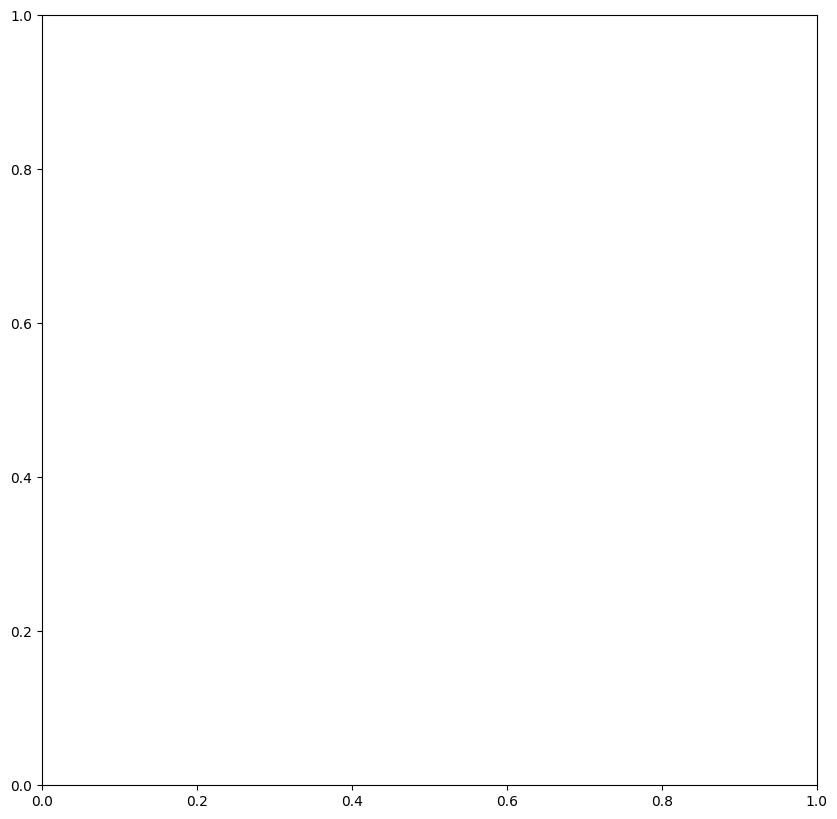

In [190]:
tp.annotate(f,frames,)

In [170]:
t_=t[t['frame']==1]
x=list(t_['x'])
y=list(t_['y'])

In [175]:
x[1],y[1]

(182.53107019562717, 157.1513233601841)

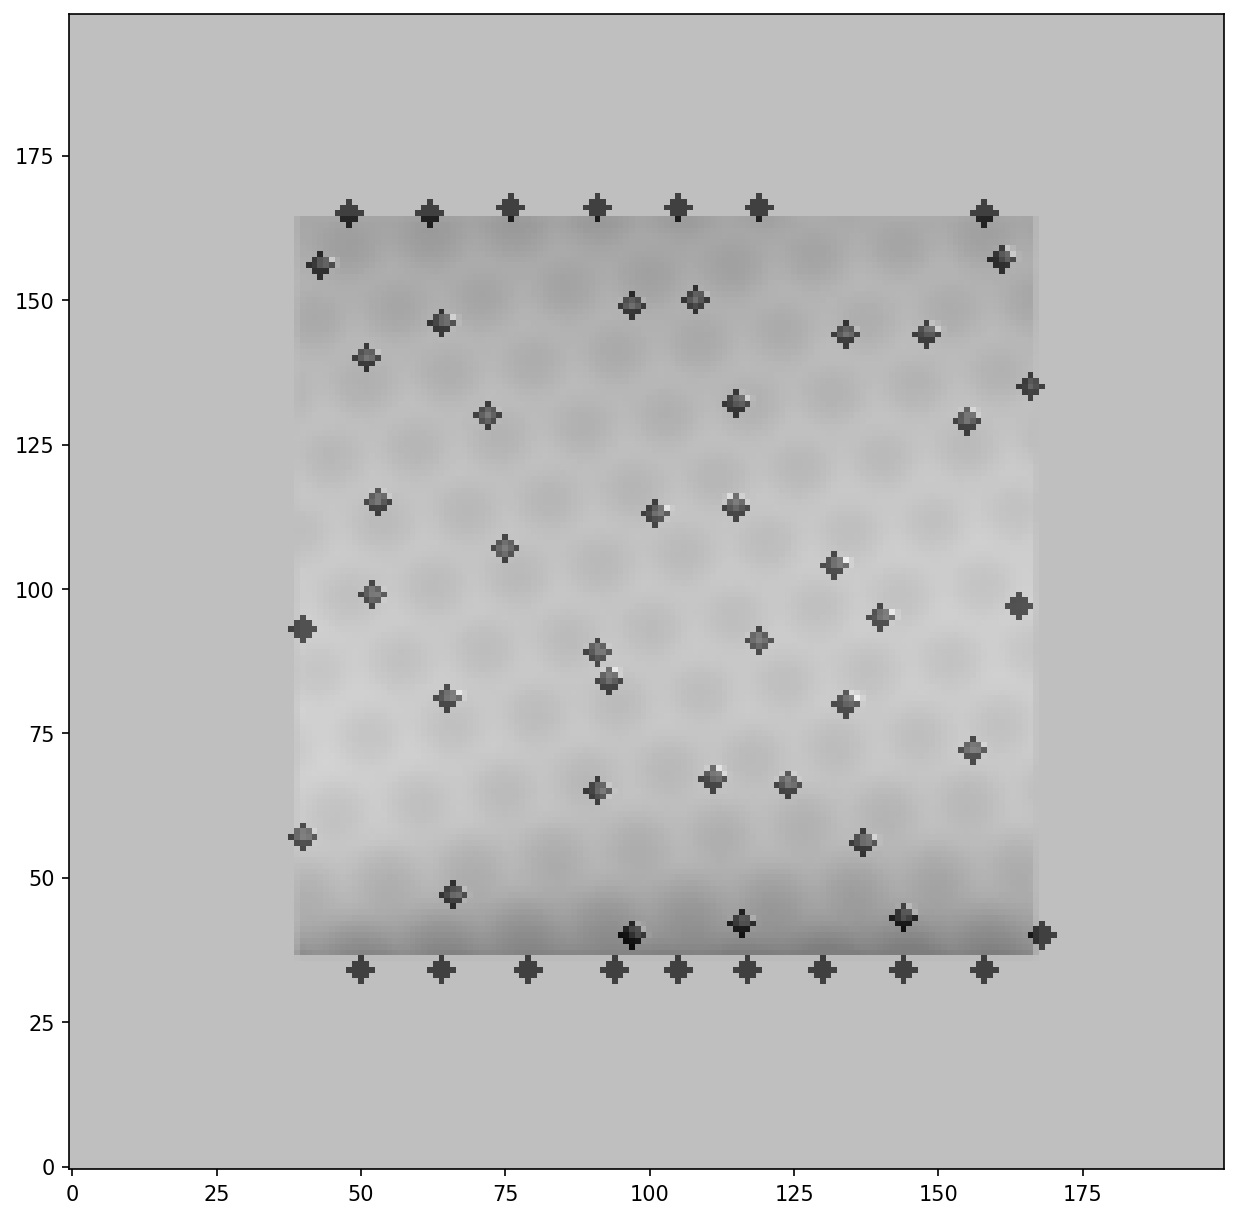

In [200]:
plt.imshow(mask_from_points(t,1,int(5/2),200),zorder=2,alpha=0.5)
plt.imshow(new[1],)
plt.show()

In [9]:

def crop_center(frame, crop_width, crop_height):
    """Crop the center region of an image."""
    h, w = frame.shape[:2]
    start_x = (w - crop_width) // 2
    start_y = (h - crop_height) // 2
    return frame[start_y:start_y+crop_height, start_x:start_x+crop_width]

def mask_from_points(t,frame,diameter,size):
    """Creates a mask so that the image alignment doesnt look at the particles
    t is df from trackpy.link"""
    mask = np.ones((size, size), dtype=np.uint8) * 255  # Use entire image
    t_=t[t['frame']==frame]
    x=list(t_['x'])
    y=list(t_['y'])
    for i in range(len(x)):
        cv2.circle(mask, (int(x[i]), int(y[i])), int(diameter/2), 0, thickness=-1)
    return mask
def align_frames(template, image,drift_estimate,mask):
    """
    Compute the translation aligning 'image' to 'template'.
    First try using ECC. If ECC fails (e.g. does not converge),
    fall back to phase correlation.
    """
    warp_mode = cv2.MOTION_TRANSLATION
    # Initialize the warp matrix as identity.
    warp_matrix = warp_matrix = np.array([[1, 0, drift_estimate[1]], #drifts returns y,x
                        [0, 1, drift_estimate[0]]], dtype=np.float32)
    # Set ECC termination criteria: maximum iterations and epsilon.
    number_of_iterations = 5000
    termination_eps = 1e-6
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
                number_of_iterations, termination_eps)
    
    try:
        # Convert images to float32 (ECC works best with float images).
        template_f = template.astype(np.float32)
        image_f = image.astype(np.float32)
        # findTransformECC returns the enhanced correlation coefficient and warp matrix.
        cc, warp_matrix = cv2.findTransformECC(template_f, image_f, warp_matrix,
                                                 warp_mode, criteria,input_mask=mask)
    except cv2.error as e:
        # Fallback: use phase correlation to estimate translation.
        template_f = np.float32(template)
        image_f = np.float32(image)
        (shift_x, shift_y), response = cv2.phaseCorrelate(template_f, image_f)
        warp_matrix = np.array([[1, 0, shift_x],
                                [0, 1, shift_y]], dtype=np.float32)
    
    return warp_matrix

def main(frames,t,radius,output_crop=None,overide=[[],[]],input_crop=None,):
    #reader = SXMReader(SXM_PATH[0], channel="Z", correct="plane")  # Adjust parameters as needed
    #frames=reader
    #frames = [np.array(frame) for frame in reader]  # Convert to NumPy arrays
    drift_estimate=tp.compute_drift(t)
    camera_drifts=[]
    # Determine if the first frame is color.
    if frames[0].ndim == 2:
        is_color = False
    else:
        # Assume color if there are 3 or 4 channels.
        is_color = True

    cropped_frames = []
    if output_crop==None:
        output_crop=np.shape(frames)[1]
    # Crop each frame to its center region and standardize channel numbers.
    for frame in frames:
        if input_crop==None:
            cropped=frame
        else:
            cropped = crop_center(frame, input_crop, input_crop)
        # If we expect color but the frame is grayscale, convert to RGB.
        if is_color and cropped.ndim == 2:
            cropped = cv2.cvtColor(cropped, cv2.COLOR_GRAY2RGB)
        # If the frame has an alpha channel, convert from RGBA to RGB.
        elif is_color and cropped.ndim == 3 and cropped.shape[2] == 4:
            cropped = cv2.cvtColor(cropped, cv2.COLOR_RGBA2RGB)

        cropped_frames.append(cropped)
    
    # Create grayscale versions for alignment computation.
    if is_color:
        cropped_gray = [cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY) for frame in cropped_frames]
    else:
        cropped_gray = cropped_frames

    aligned_frames = []         # To store the drift-corrected frames.
    cumulative_translation = np.array([0, 0], dtype=np.float32)
    
    # The first frame is used as the reference.
    image_shift=(output_crop-cropped.shape[1])/2

    M = np.array([[1, 0, image_shift],
                  [0, 1,image_shift]], dtype=np.float32)
    warped = cv2.warpAffine(cropped_frames[0], M, (output_crop, output_crop),
                        flags=cv2.INTER_LINEAR)
    aligned_frames.append(warped)

    prev_gray = cropped_gray[0]

    # Process each pair of consecutive frames.
    for i in range(1, len(cropped_frames)):
        curr_gray = cropped_gray[i]
        # Compute translation from previous frame to current frame.
        mask=mask_from_points(t,i,radius,output_crop)

        warp_matrix = align_frames(prev_gray, curr_gray,drift_estimate.loc[i],mask)
        if i in overide[0]:
            dx =overide[1][overide[0].index(i)][0]
            dy=overide[1][overide[0].index(i)][1]
        else:
            dy = warp_matrix[1, 2]
            dx = warp_matrix[0, 2]
        camera_drifts.append([dx,dy])
        cumulative_translation += np.array([dx, dy], dtype=np.float32)
        
        # Create a translation matrix to warp the current frame to align with the reference.
        M = np.array([[1, 0, -cumulative_translation[0]+image_shift],
                      [0, 1, -cumulative_translation[1]+image_shift]], dtype=np.float32)

        # Apply the translation warp.
        warped = cv2.warpAffine(cropped_frames[i], M, (output_crop, output_crop),
                                flags=cv2.INTER_LINEAR)
        aligned_frames.append(warped)

        # Update the reference (using the original gray version for this frame).
        prev_gray = curr_gray

    return(aligned_frames)


In [109]:
#for i in output:
 #   plt.figure()
  #  plt.imshow(i)
   # plt.show()
path='test.gif'
aligned_frames_uint8 = [np.uint8(np.clip(frame, 0, 255)) for frame in output]


imageio.mimsave(path, aligned_frames_scaled, duration=0.1)


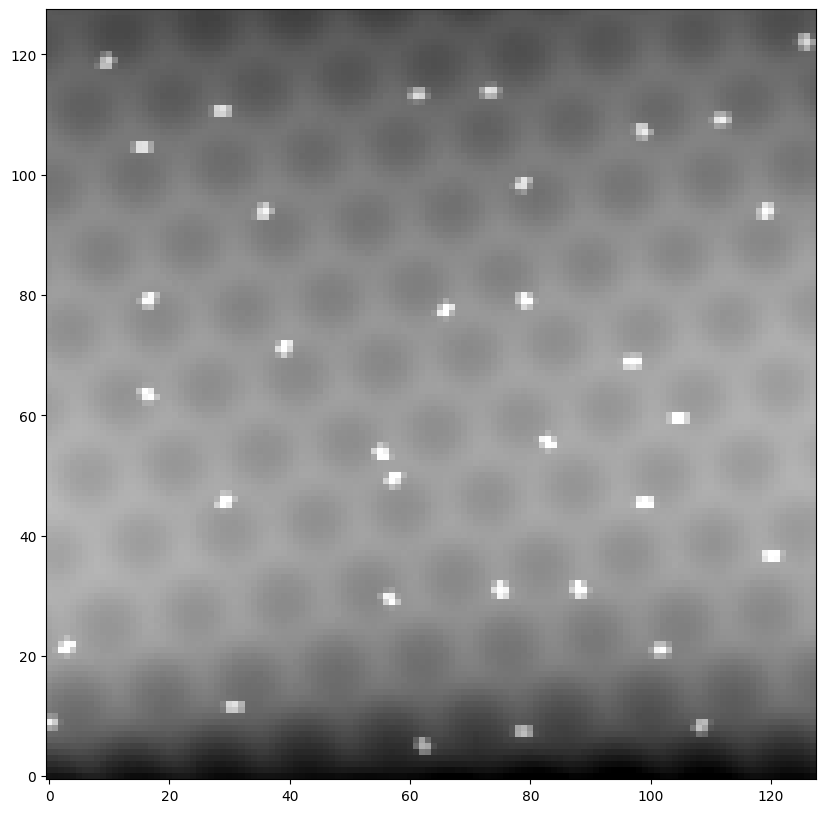

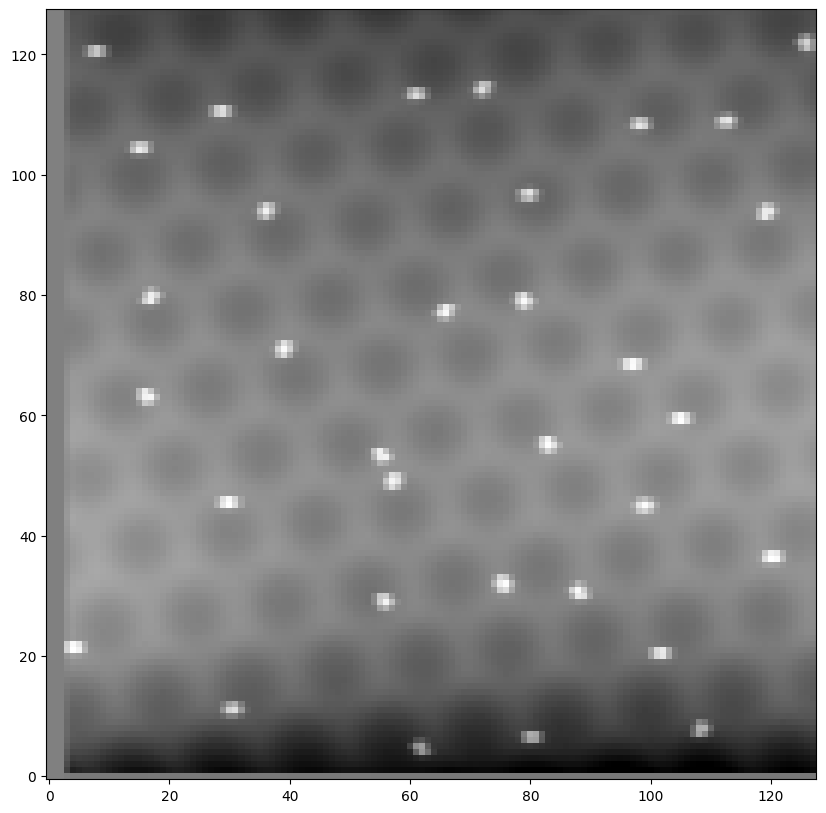

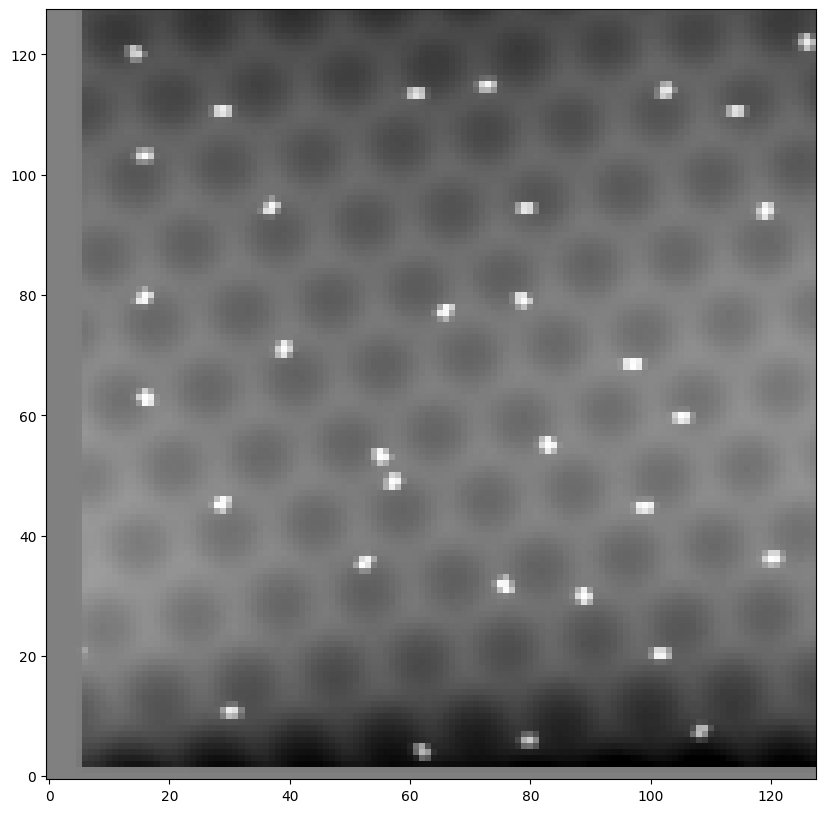

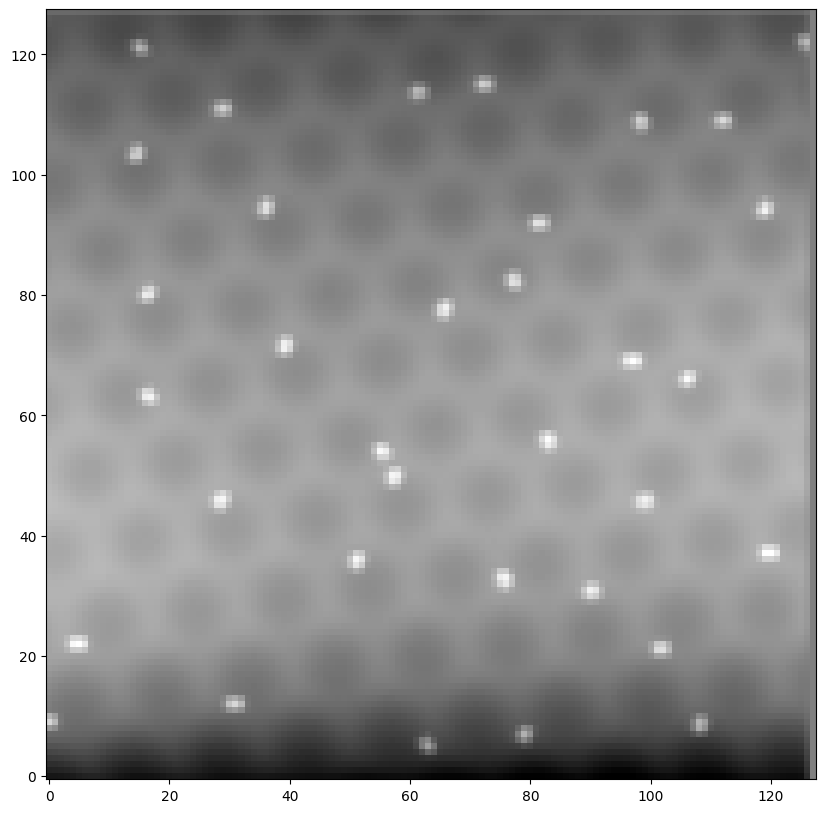

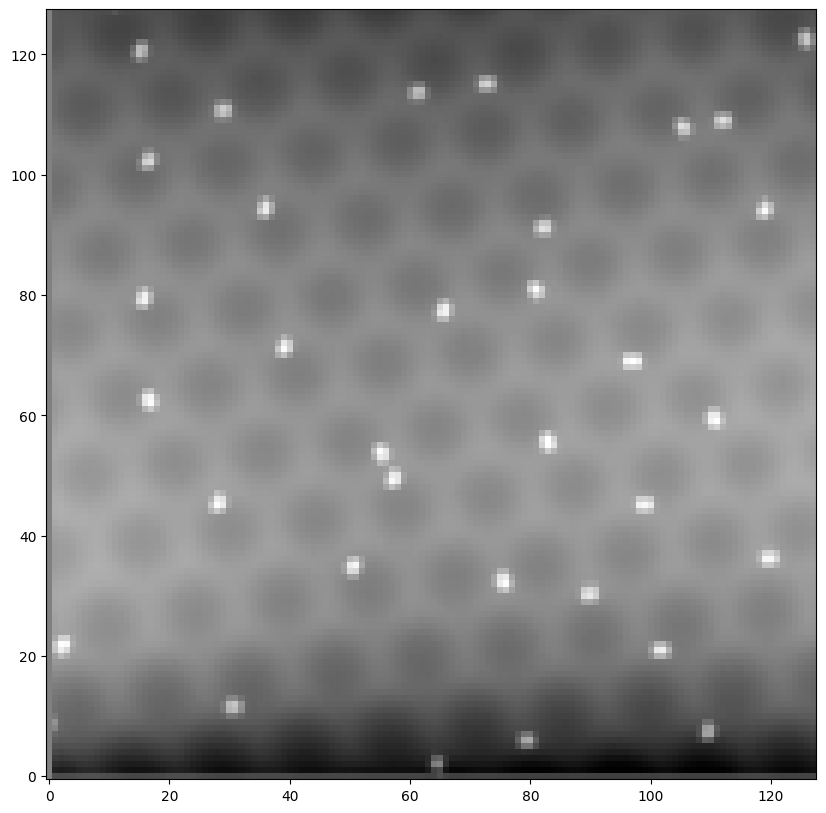

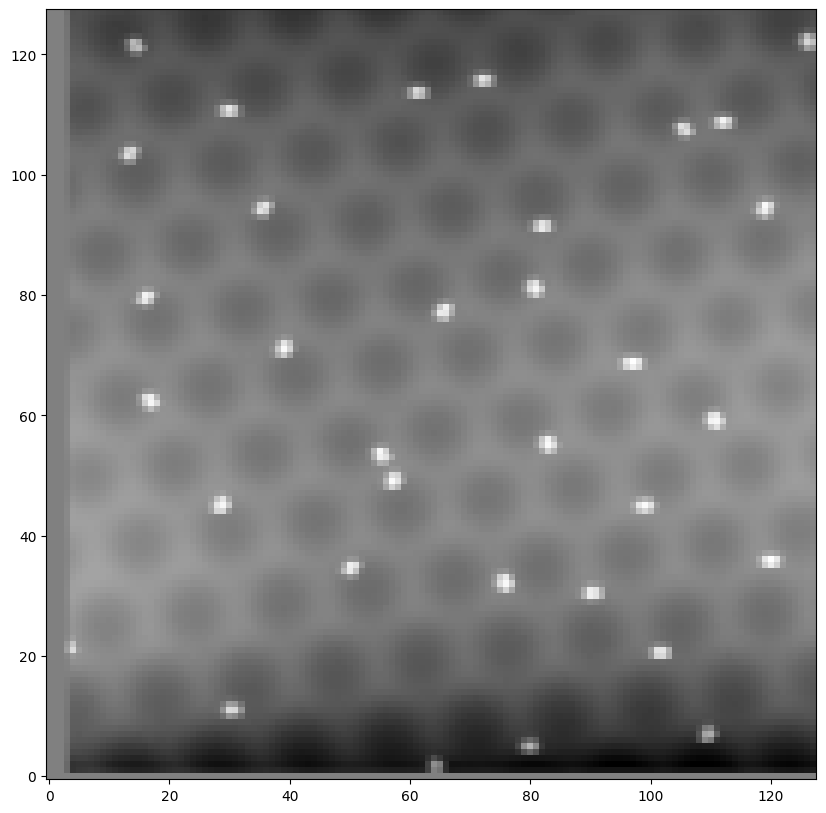

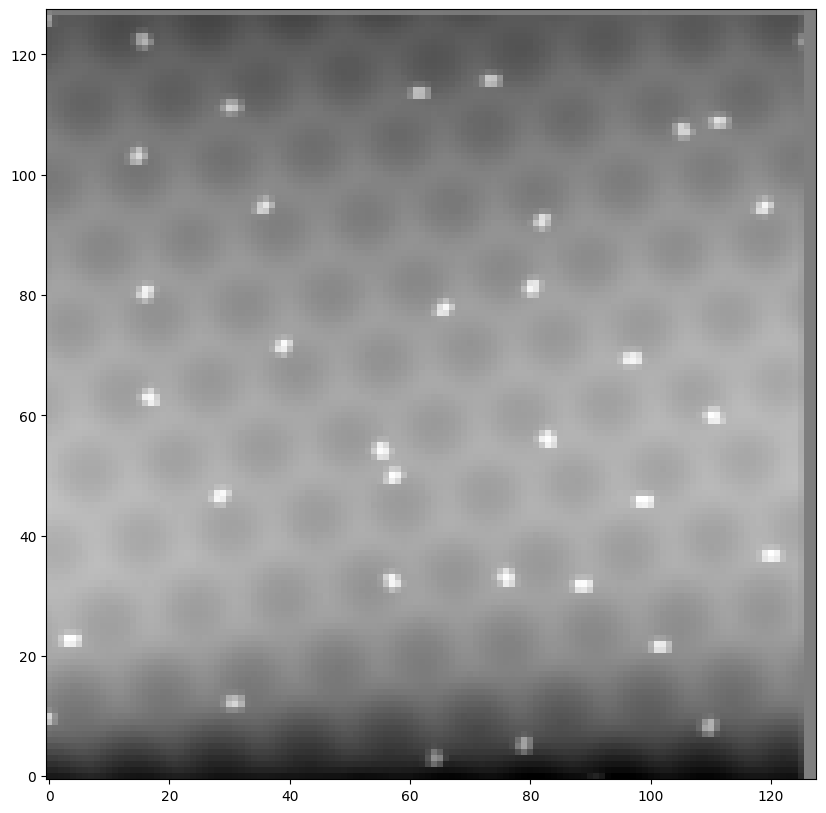

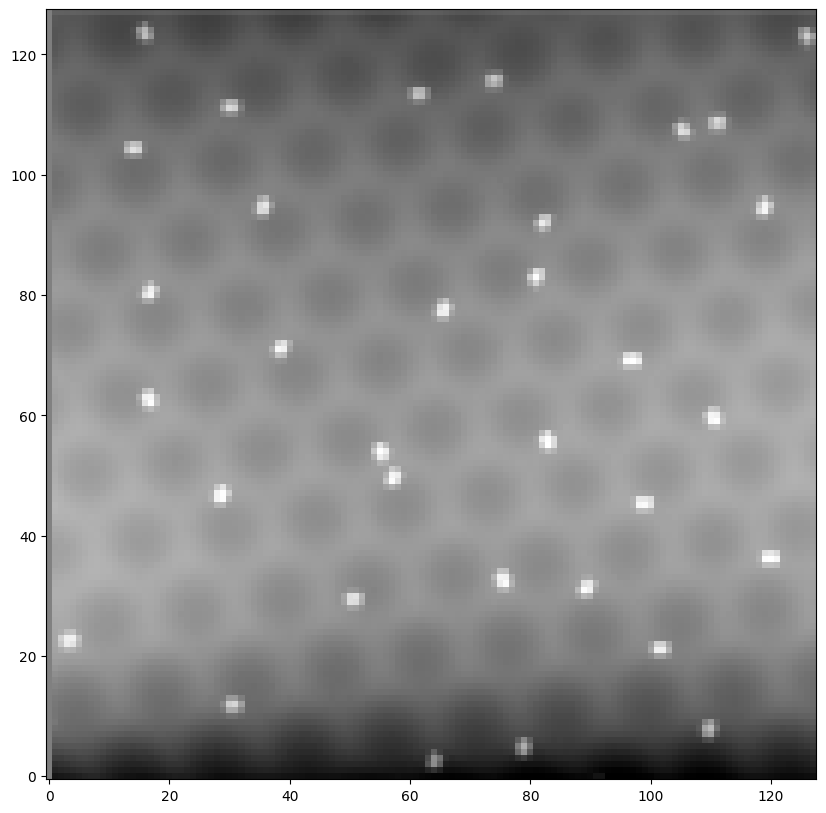

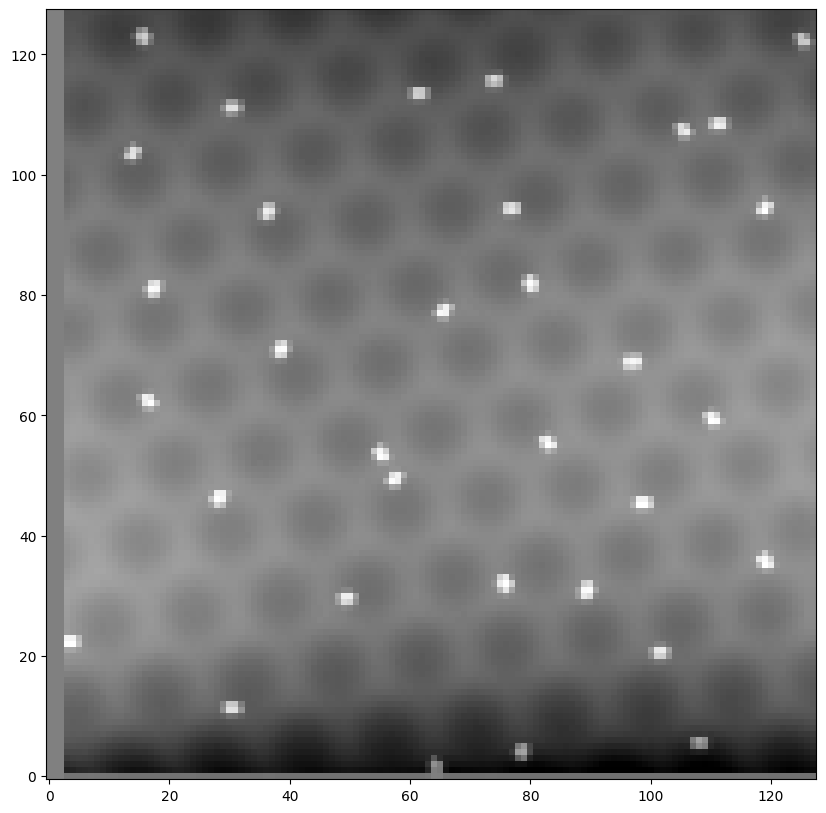

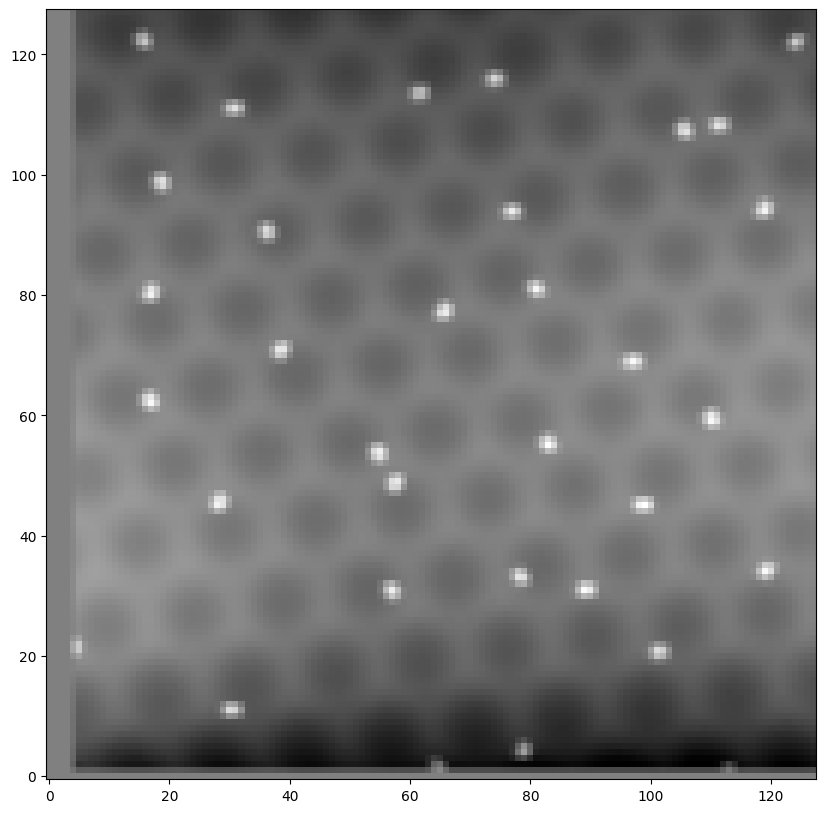

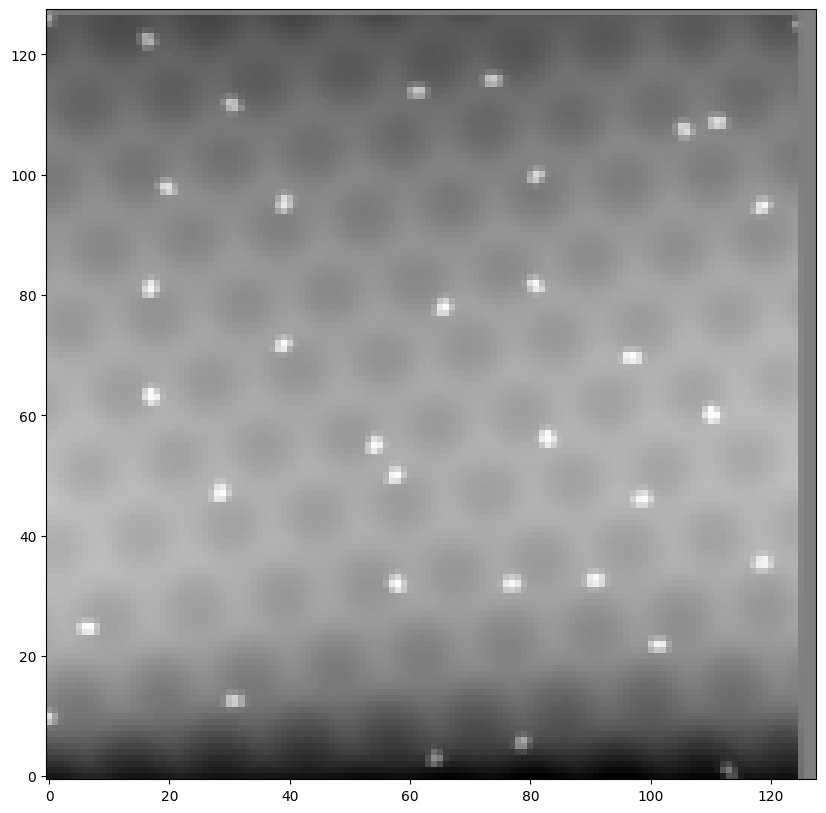

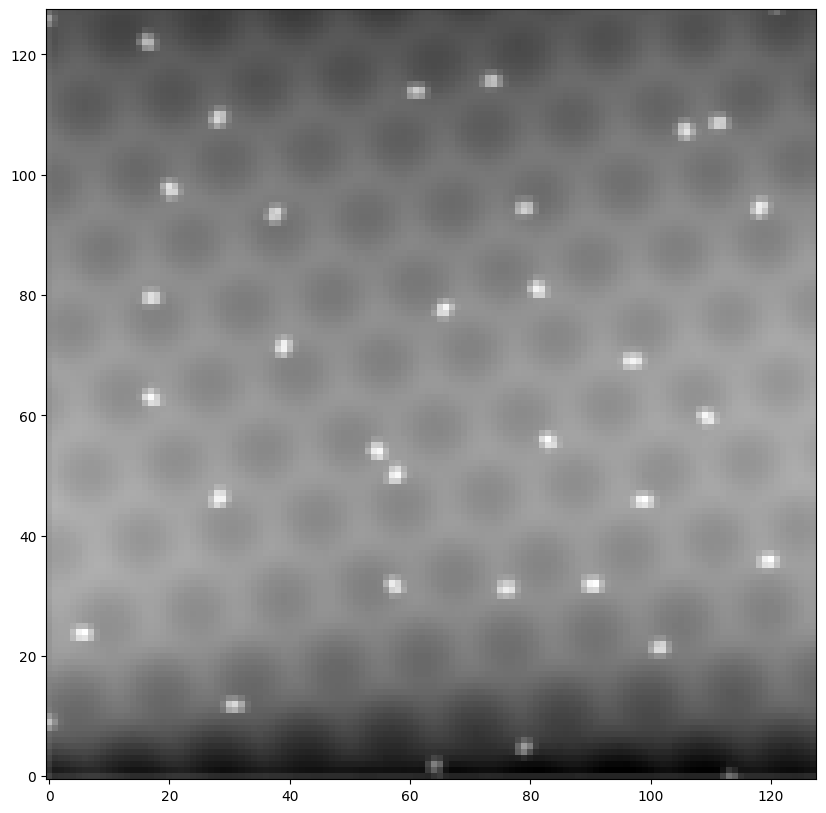

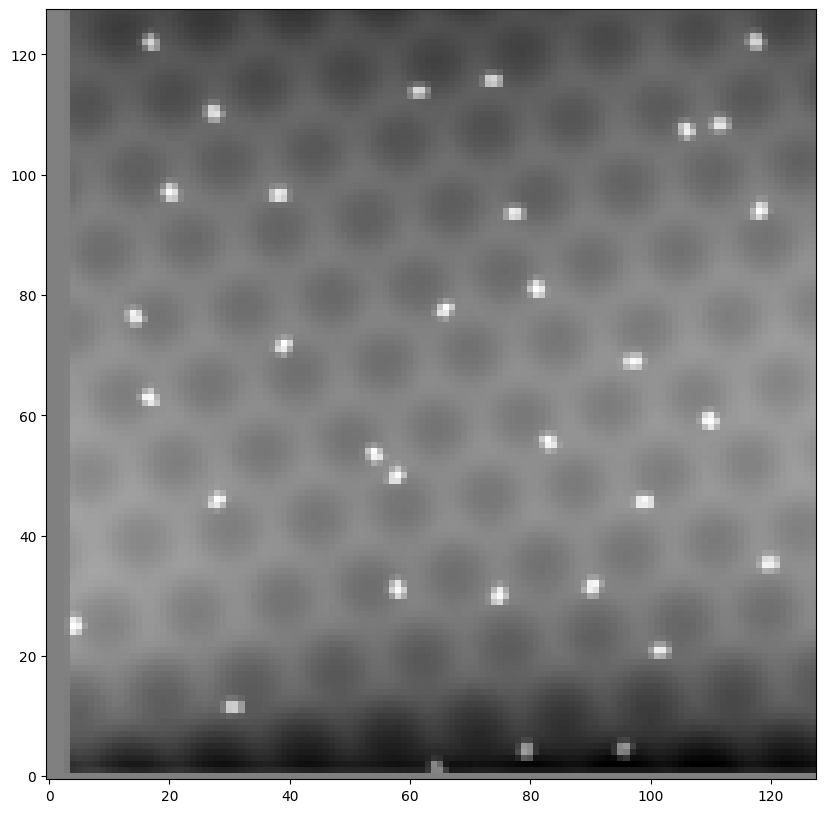

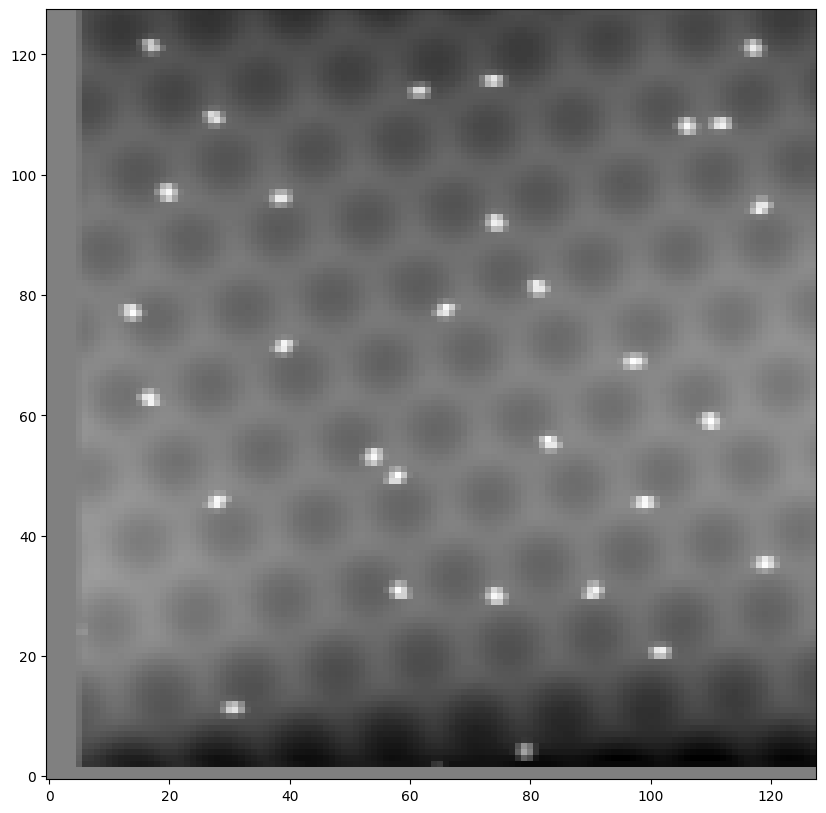

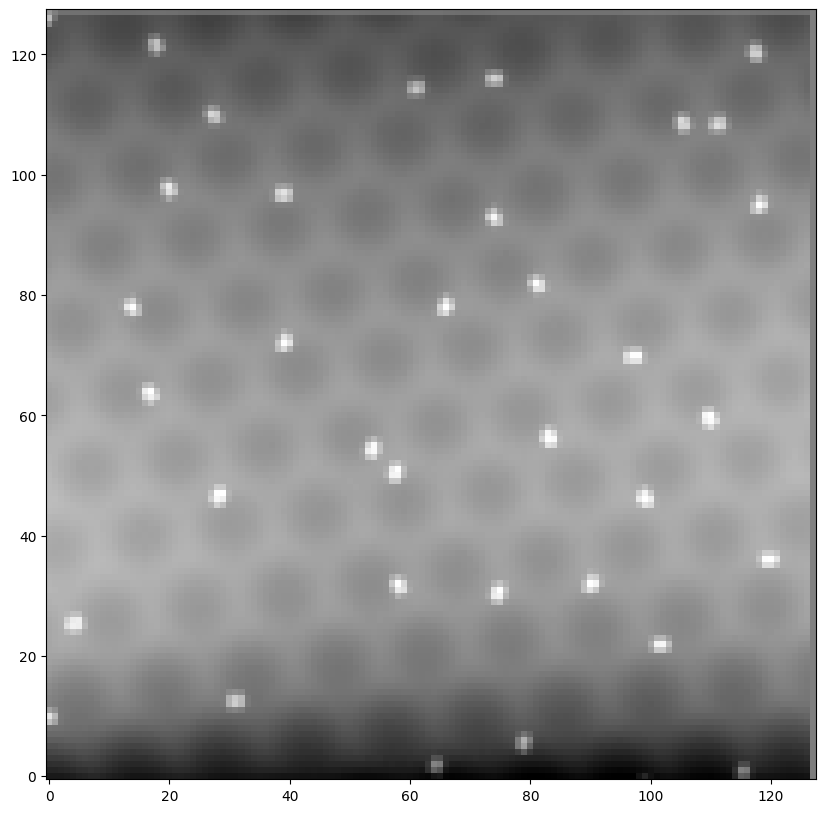

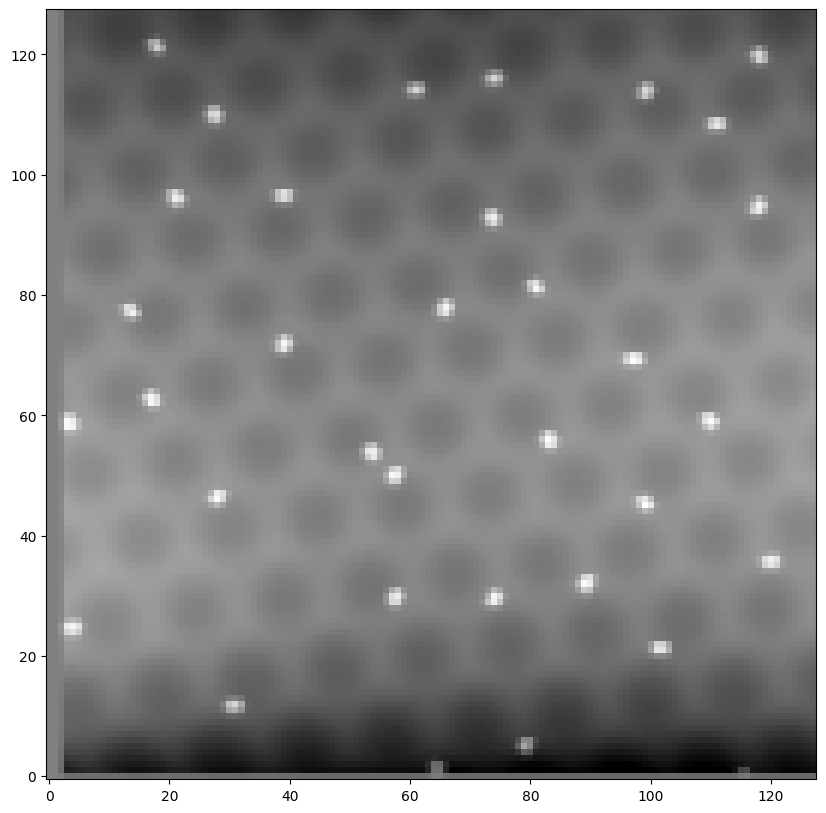

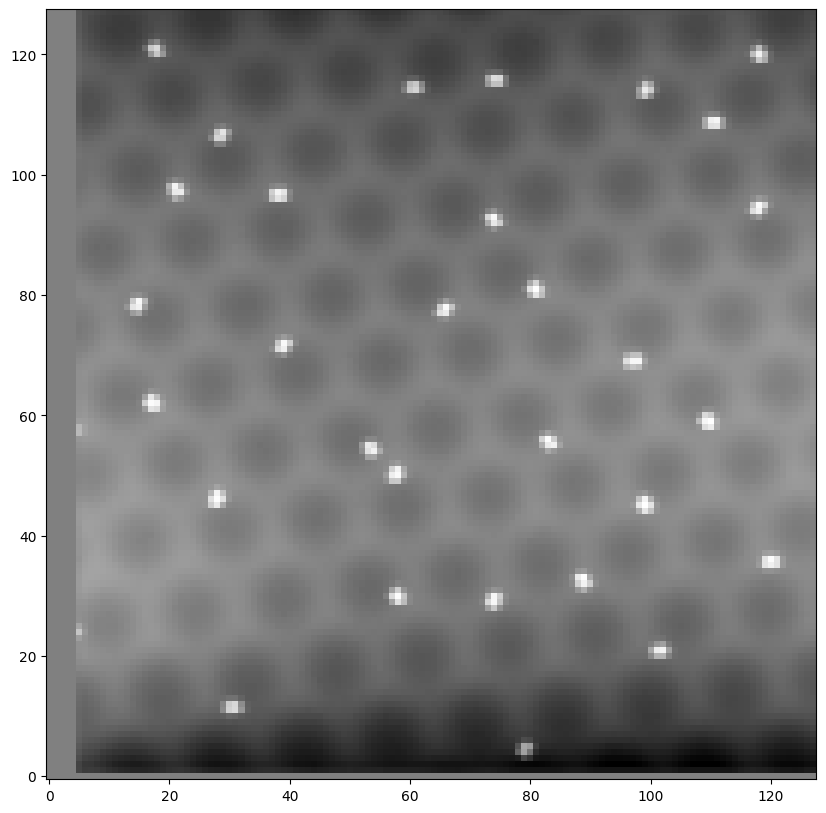

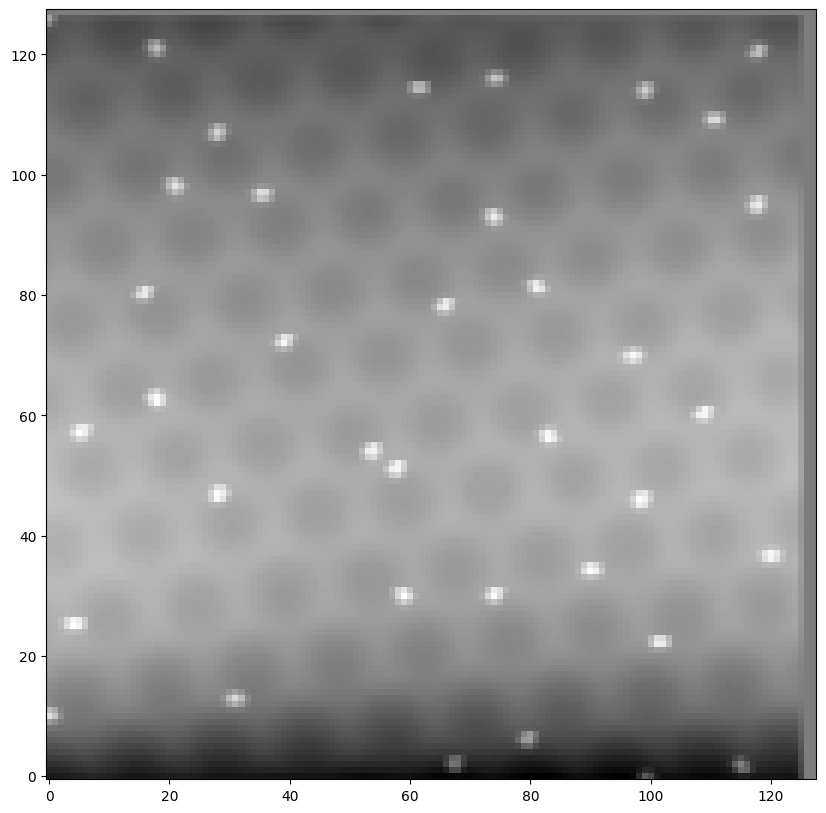

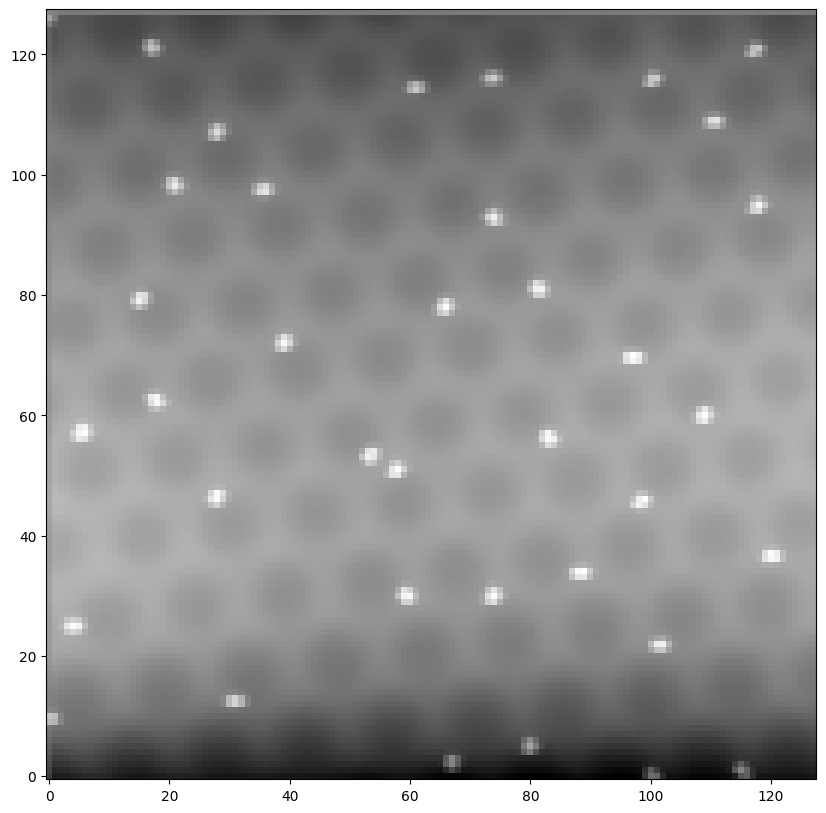

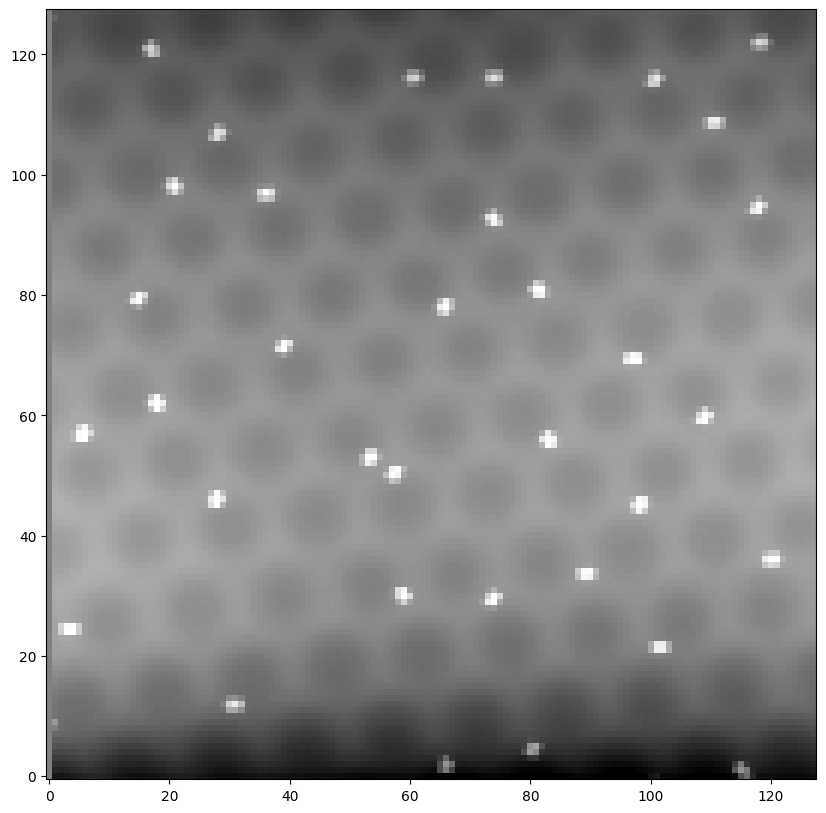

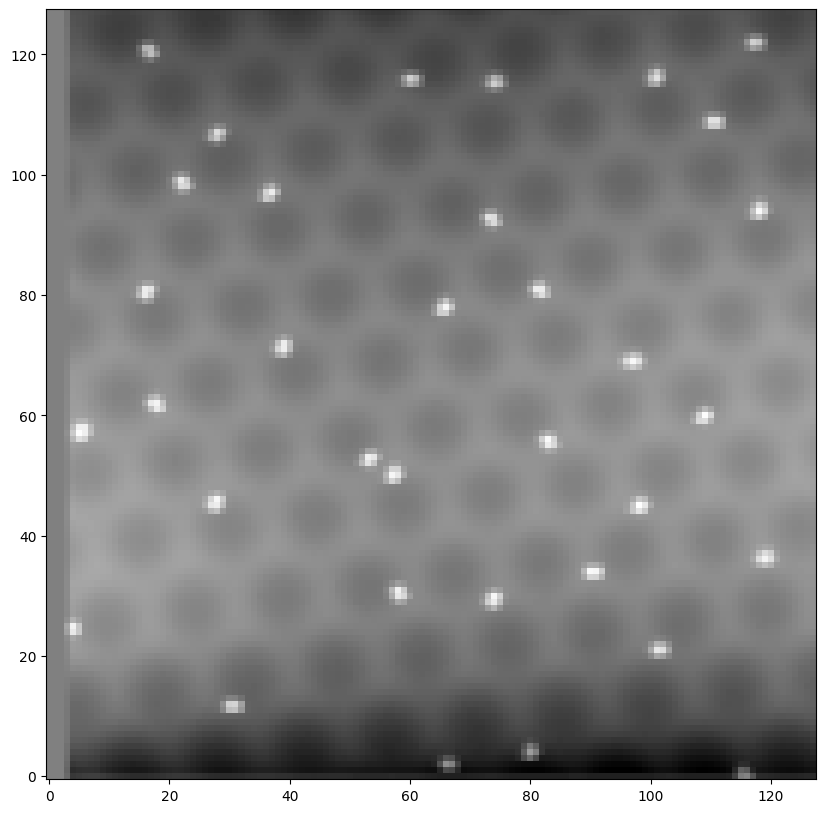

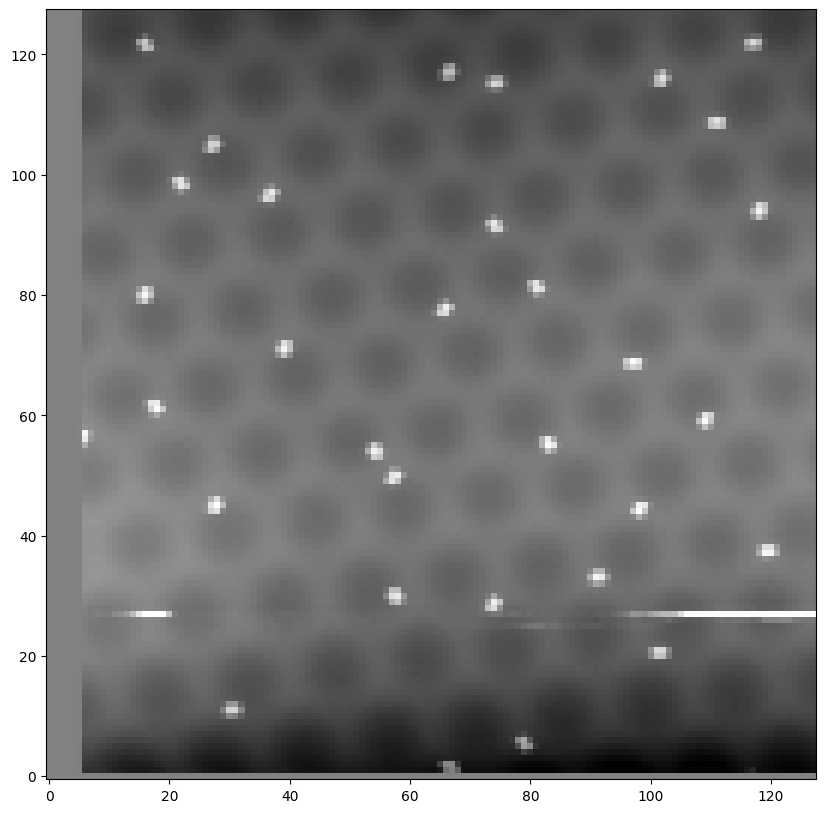

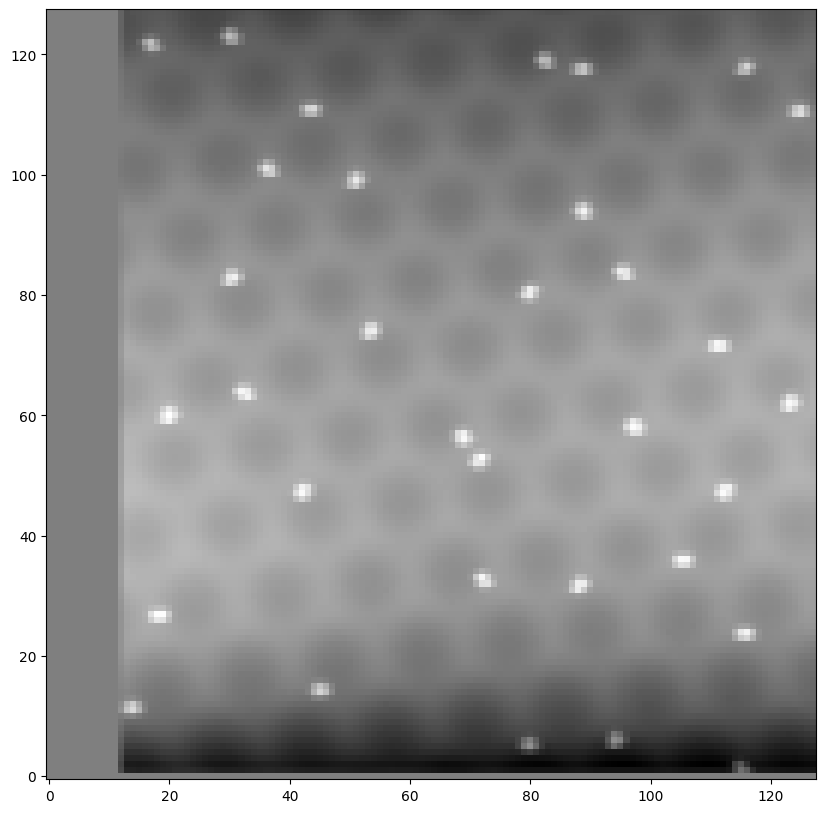

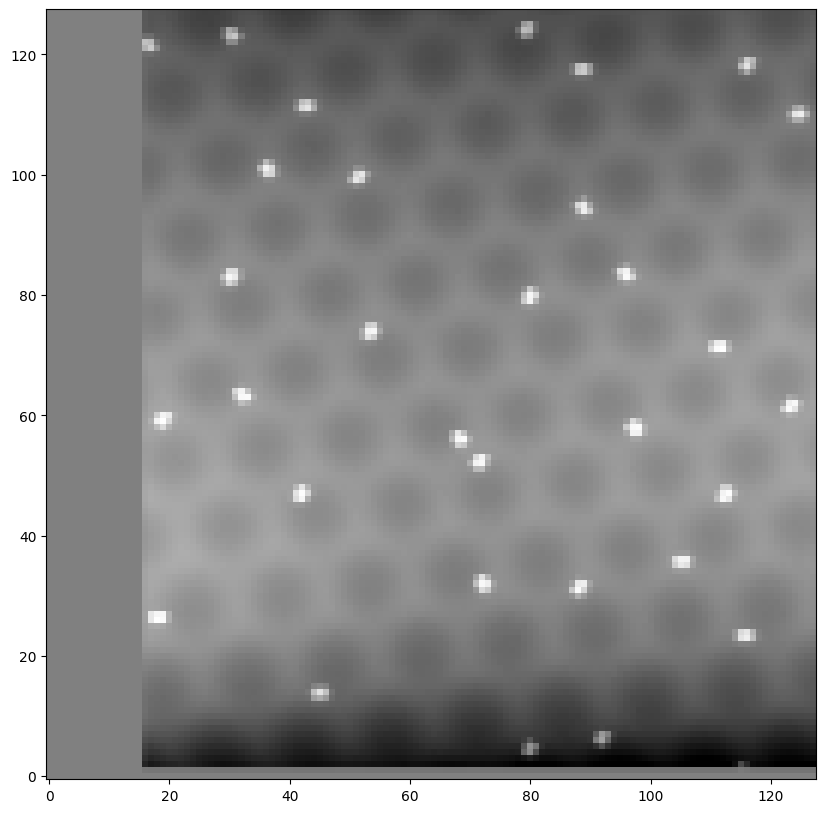

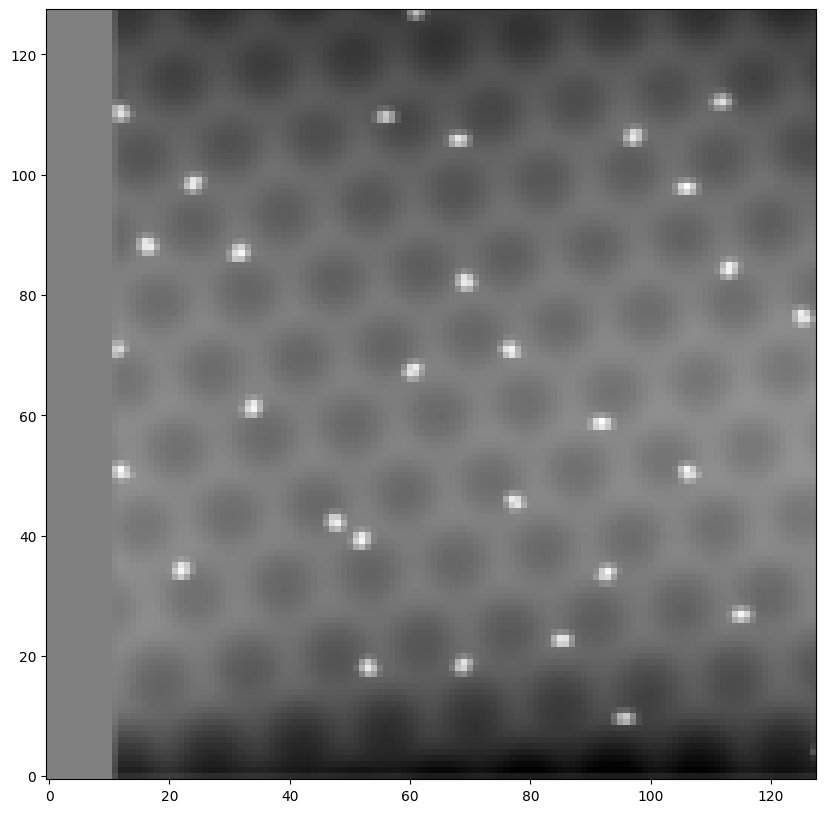

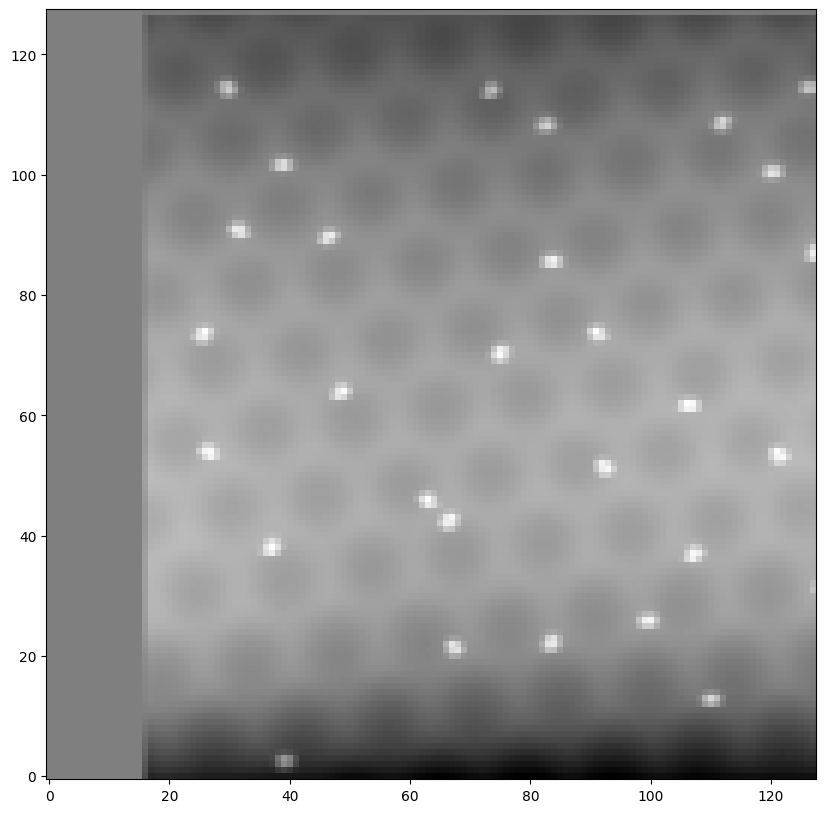

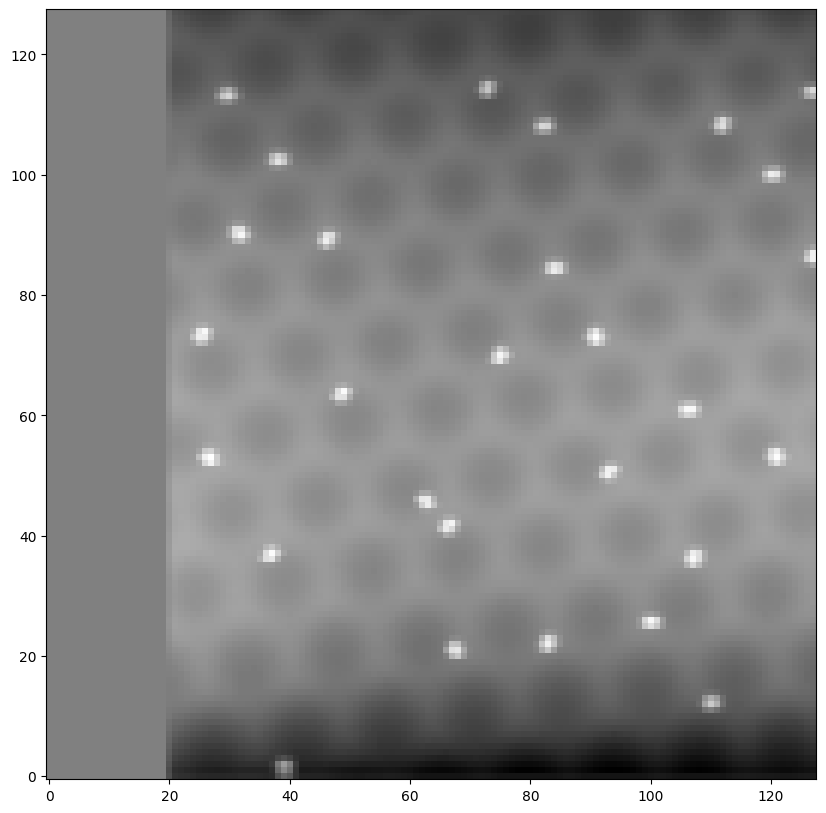

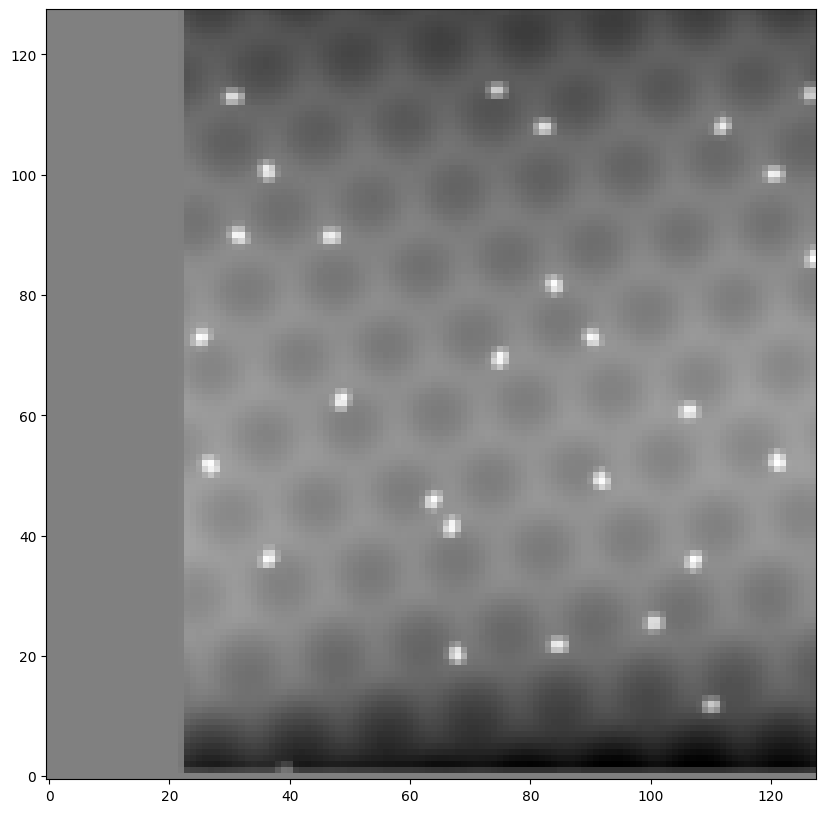

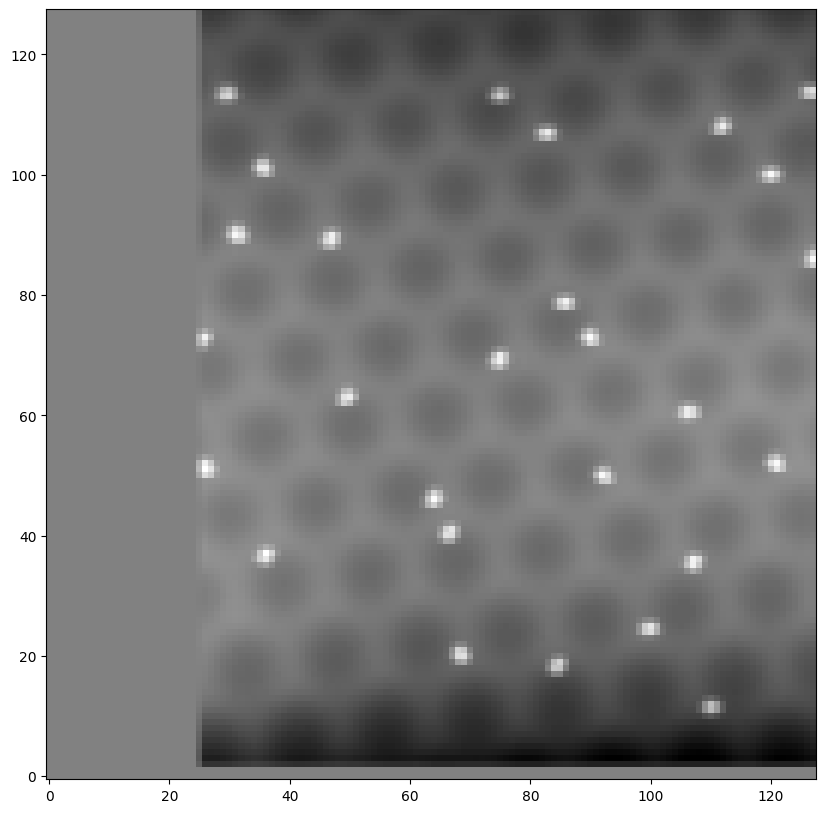

In [108]:
for i in aligned_frames_scaled:
    plt.figure()
    plt.imshow(i)
    plt.show()